## Look at structural similarity in the test set


In [1]:
import tarfile
import tempfile

import pandas as pd

In [2]:
data_dir="../data/scratch/rosetta/"

In [3]:
test_variants = pd.read_csv(f"{data_dir}/2D_splits/test_variants.txt", header=None)
test_variants.columns = ["variants"]

In [4]:
for variant in test_variants.variants:
    break

In [16]:
cmp_to_ref = pd.read_csv(
    f"../alphafold/dist_scores/results/ref_comparison.txt", 
    header=None, sep="\t")
cmp_to_ref.columns=["struct1", "struct2", "TM1", "TM2", 
                    "RMSD", "ID1", "ID2", "IDali", "L1",
                    "L2", "Lali", "GDTTS", "GDTHA"]

In [17]:
cmp_to_repeat = pd.read_csv(
    f"../alphafold/dist_scores/results/repeat_comparison.txt",
        header=None, sep="\t")
cmp_to_repeat.columns = cmp_to_ref.columns

In [21]:
import seaborn as sns

In [30]:
comps_ref = cmp_to_ref[["TM2", "GDTTS", "RMSD"]].copy()
comps_ref["id"] = "ref"

In [32]:
comps_repeat = cmp_to_repeat[["TM2", "GDTTS", "RMSD"]].copy()
comps_repeat["id"] = "repeat"

In [33]:
comps = pd.concat([comps_ref, comps_repeat])

In [36]:
comps_melt = pd.melt(comps, id_vars=["id"])

In [38]:
comps_melt.columns

Index(['id', 'variable', 'value'], dtype='object')

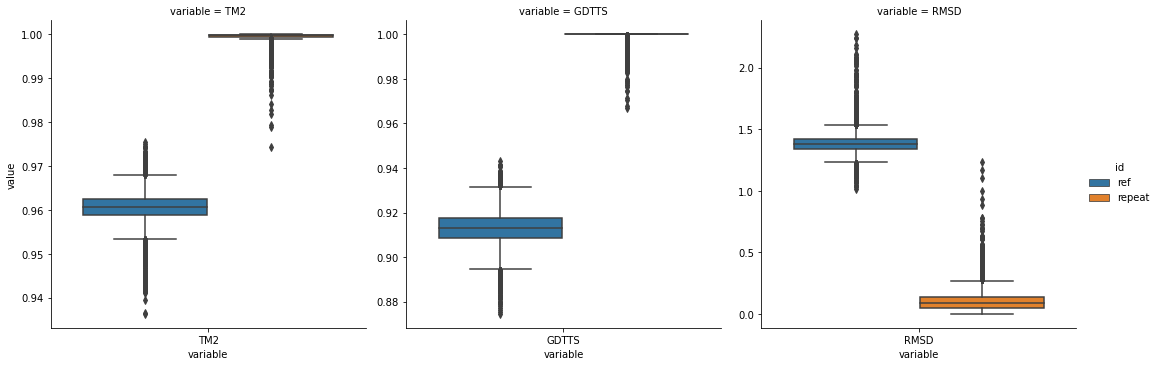

In [47]:
sns.catplot(x="variable", y="value", hue="id", col="variable",
                 data=comps_melt, kind="box", sharey=False, sharex=False)